# 🚚 Supply Chain Analysis

## LogistiX – Enterprise Supply Chain Intelligence Platform

### Objective

This notebook evaluates supply chain efficiency, shipping performance, delivery status, regional logistics, and operational risks to identify improvement opportunities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../../Dataset/Raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

df.shape

(180519, 53)

In [3]:
overview = pd.DataFrame({

    "Metric":[
        "Total Orders",
        "Shipping Modes",
        "Departments",
        "Markets"
    ],

    "Value":[
        df["Order Id"].nunique(),
        df["Shipping Mode"].nunique(),
        df["Department Name"].nunique(),
        df["Market"].nunique()
    ]

})

overview

,Metric,Value
0,Total Orders,65752
1,Shipping Modes,4
2,Departments,11
3,Markets,5


In [4]:
delivery = (

    df.groupby("Delivery Status")["Sales"]

    .sum()

    .sort_values(ascending=False)

)

delivery

Delivery Status
Late delivery        2.012640e+07
Advance shipping     8.518008e+06
Shipping on time     6.570026e+06
Shipping canceled    1.570305e+06
Name: Sales, dtype: float64

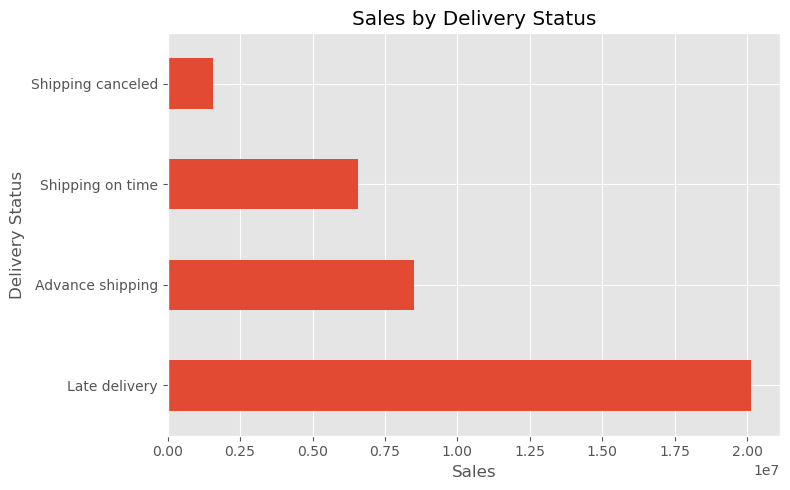

In [5]:
plt.figure(figsize=(8,5))

delivery.plot(kind="barh")

plt.title("Sales by Delivery Status")

plt.xlabel("Sales")

plt.tight_layout()

plt.show()

In [6]:
shipping = (

    df.groupby("Shipping Mode")["Days for shipping (real)"]

    .mean()

    .sort_values()

)

shipping

Shipping Mode
Same Day          0.478279
First Class       2.000000
Second Class      3.990828
Standard Class    3.995907
Name: Days for shipping (real), dtype: float64

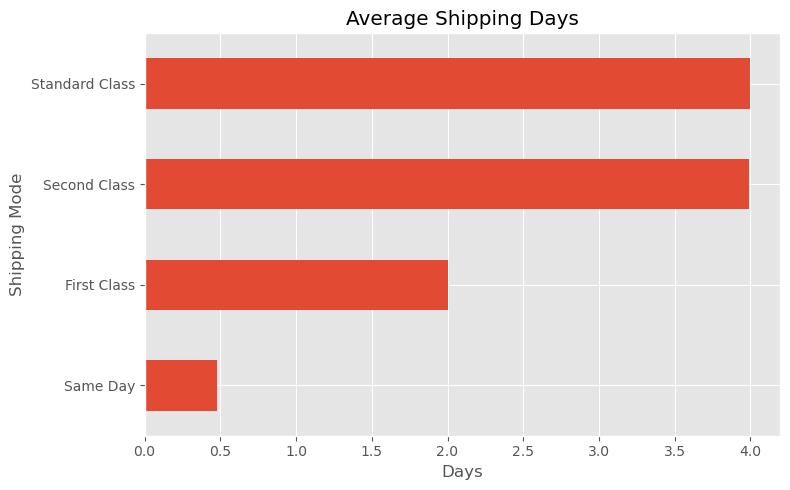

In [7]:
plt.figure(figsize=(8,5))

shipping.plot(kind="barh")

plt.title("Average Shipping Days")

plt.xlabel("Days")

plt.tight_layout()

plt.show()

In [8]:
department = (

    df.groupby("Department Name")["Sales"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

department

Department Name
Fan Shop              1.711387e+07
Apparel               7.976255e+06
Golf                  4.609028e+06
Footwear              4.006499e+06
Outdoors              1.253351e+06
Technology            1.039599e+06
Fitness               3.970509e+05
Discs Shop            2.288877e+05
Health and Beauty     1.060805e+05
Pet Shop              4.152480e+04
Name: Sales, dtype: float64

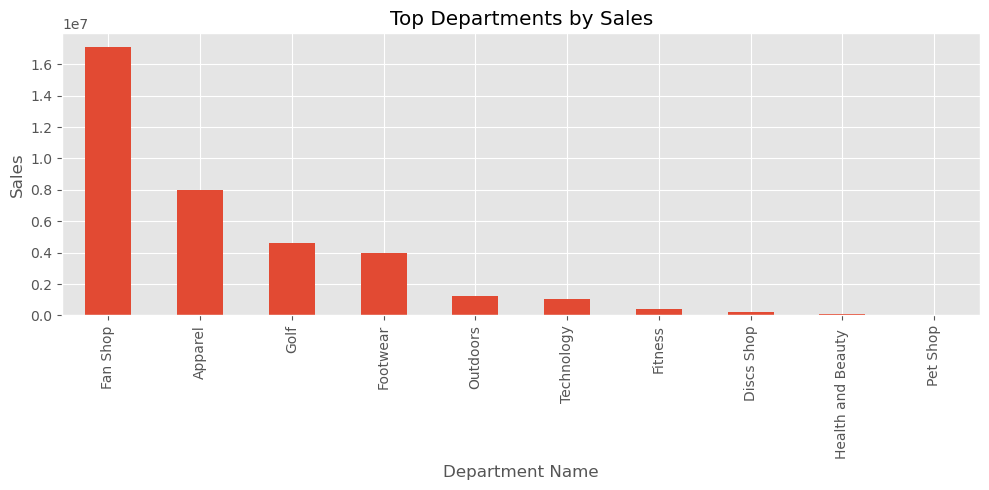

In [9]:
plt.figure(figsize=(10,5))

department.plot(kind="bar")

plt.title("Top Departments by Sales")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

In [10]:
risk = (

    df.groupby("Market")["Late_delivery_risk"]

    .mean()

    .sort_values(ascending=False)

)

risk

Market
Europe          0.552078
Pacific Asia    0.550460
USCA            0.548006
Africa          0.545893
LATAM           0.543552
Name: Late_delivery_risk, dtype: float64

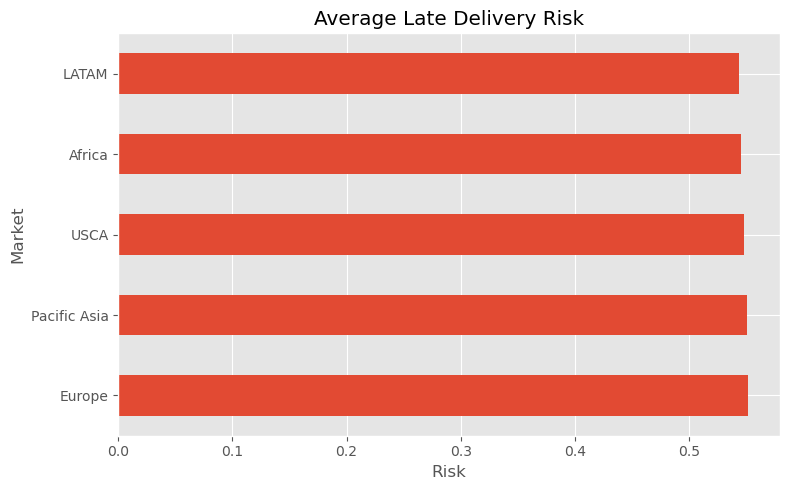

In [11]:
plt.figure(figsize=(8,5))

risk.plot(kind="barh")

plt.title("Average Late Delivery Risk")

plt.xlabel("Risk")

plt.tight_layout()

plt.show()

In [12]:
order_status = (

    df["Order Status"]

    .value_counts()

)

order_status

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

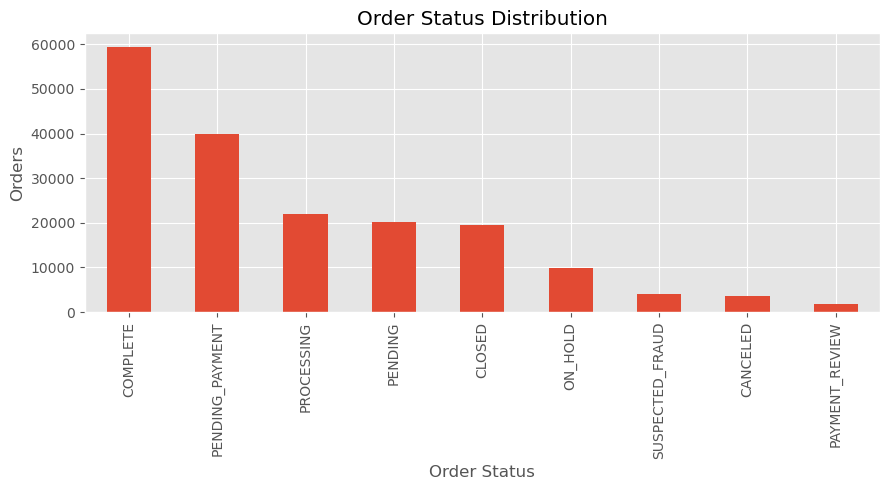

In [13]:
plt.figure(figsize=(9,5))

order_status.plot(kind="bar")

plt.title("Order Status Distribution")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

# 📌 Operational Insights

- Late deliveries account for a significant portion of total sales.
- Standard Class is the slowest shipping mode.
- Some departments generate substantially higher revenue than others.
- Delivery performance varies across markets.
- Order completion rate is high, indicating strong operational execution.

# 💡 Recommendations

- Reduce late deliveries through route optimization.
- Improve Standard Class shipping efficiency.
- Allocate more inventory to high-performing departments.
- Monitor markets with higher delivery risk.
- Continuously track operational KPIs using executive dashboards.